# Étude du déséquilibre des classes

Ce notebook étudie l'impact du déséquilibre des classes sur les deux modèles : la régression logistique associée à BoW et RoBERTa.

Deux scénarios sont considérés :
- 80 % d'avis authentiques et 20 % de faux avis ;
- 90 % d'avis authentiques et 10 % de faux avis.

Les performances des deux modèles seront d'abord évaluées sans correction
du déséquilibre, puis une pondération des classes sera appliquée afin
d'étudier son effet sur leurs performances.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [24]:
from pathlib import Path
import socket

HOSTNAME = socket.gethostname()

PROJECT_DIR = (
    Path.home() / "amazon_reviews_experimentation"
    if HOSTNAME == "cybernemo-main-worker-GPU1"
    else Path.cwd().parent
)

DATA_DIR = PROJECT_DIR / "data"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_DIR / "amazon_reviews_preprocessed.csv"

print("Machine :", HOSTNAME)
print("Dossier du projet :", PROJECT_DIR)
print("Fichier utilisé :", file_path)

df = pd.read_csv(file_path)
df.head()

Machine : cybernemo-main-worker-GPU1
Dossier du projet : /home/siham/amazon_reviews_experimentation
Fichier utilisé : /home/siham/amazon_reviews_experimentation/data/amazon_reviews_preprocessed.csv


,DOC_ID,REVIEW_TEXT,preprocessed_text,VERIFIED_PURCHASE,review_word_count,LABEL,label_num
0,1,"When least you think so, this product will sav...",least think product save day keep around case ...,N,23,fake,1
1,2,Lithium batteries are something new introduced...,lithium batteri someth new introduc market ave...,Y,69,fake,1
2,3,I purchased this swing for my baby. She is 6 m...,purchas swing babi 6 month pretti much grown l...,N,52,fake,1
3,4,I was looking for an inexpensive desk calcolat...,look inexpens desk calcolatur work everyth nee...,N,44,fake,1
4,5,I only use it twice a week and the results are...,use twice week result great use teeth whiten s...,N,66,fake,1


In [25]:
print("Nombre total d'avis :", len(df))

print("\nRépartition des classes :")
print(df["label_num"].value_counts())

print("\nRépartition en pourcentage :")
print(
    df["label_num"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Nombre total d'avis : 21000

Répartition des classes :
label_num
1    10500
0    10500
Name: count, dtype: int64

Répartition en pourcentage :
label_num
1    50.0
0    50.0
Name: proportion, dtype: float64


## Construction des jeux de données déséquilibrés

### Scénario 80/20

Le scénario 80/20 est construit en conservant tous les avis authentiques
et en sous-échantillonnant aléatoirement les faux avis afin d'obtenir
80 % d'avis authentiques et 20 % de faux avis.

In [26]:
# Scénario 80/20 : 80 % d'avis authentiques et 20 % de faux avis
df_authentiques = df[df["label_num"] == 0]
df_faux = df[df["label_num"] == 1]

n_faux_80_20 = int(len(df_authentiques) * 0.20 / 0.80)

df_80_20 = pd.concat([
    df_authentiques,
    df_faux.sample(n=n_faux_80_20, random_state=42)
])
df_80_20 = df_80_20.sample(frac=1, random_state=42).reset_index(drop=True)
# Sauvegarde
file_80_20 = DATA_DIR / "amazon_reviews_80_20.csv"
df_80_20.to_csv(file_80_20, index=False)
# Tableau récapitulatif
summary_80_20 = (
    df_80_20["label_num"]
    .value_counts()
    .sort_index()
    .reset_index(name="Nombre")
)
summary_80_20["Classe"] = ["Avis authentiques", "Faux avis"]
summary_80_20["Pourcentage"] = (summary_80_20["Nombre"] / len(df_80_20) * 100).round(2)
summary_80_20 = summary_80_20[["Classe", "Nombre", "Pourcentage"]]

print("Nombre total d'avis :", len(df_80_20))
print("Fichier sauvegardé :", file_80_20)
summary_80_20

Nombre total d'avis : 13125
Fichier sauvegardé : /home/siham/amazon_reviews_experimentation/data/amazon_reviews_80_20.csv


,Classe,Nombre,Pourcentage
0,Avis authentiques,10500,80.0
1,Faux avis,2625,20.0


### Scénario 90/10

Le scénario 90/10 est construit en conservant tous les avis authentiques
et en sous-échantillonnant aléatoirement les faux avis afin d'obtenir
90 % d'avis authentiques et 10 % de faux avis.

In [27]:
# Scénario 90/10 : 90 % d'avis authentiques et 10 % de faux avis
n_faux_90_10 = round(len(df_authentiques) * 0.10 / 0.90)

df_90_10 = pd.concat([
    df_authentiques,
    df_faux.sample(n=n_faux_90_10, random_state=42)
])
df_90_10 = df_90_10.sample(frac=1, random_state=42).reset_index(drop=True)

# Sauvegarde
file_90_10 = DATA_DIR / "amazon_reviews_90_10.csv"
df_90_10.to_csv(file_90_10, index=False)
# Tableau récapitulatif
summary_90_10 = (
    df_90_10["label_num"]
    .value_counts()
    .sort_index()
    .reset_index(name="Nombre")
)
summary_90_10["Classe"] = ["Avis authentiques", "Faux avis"]
summary_90_10["Pourcentage"] = (summary_90_10["Nombre"] / len(df_90_10) * 100).round(2)
summary_90_10 = summary_90_10[["Classe", "Nombre", "Pourcentage"]]

print("Nombre total d'avis :", len(df_90_10))
print("Fichier sauvegardé :", file_90_10)
summary_90_10

Nombre total d'avis : 11667
Fichier sauvegardé : /home/siham/amazon_reviews_experimentation/data/amazon_reviews_90_10.csv


,Classe,Nombre,Pourcentage
0,Avis authentiques,10500,90.0
1,Faux avis,1167,10.0


## Séparation des données

Pour chaque scénario, les données sont séparées de manière stratifiée afin de
conserver la proportion d'avis authentiques et de faux avis dans les ensembles
utilisés par les deux modèles.

La régression logistique utilise une séparation entraînement/test de 80/20, tandis que RoBERTa utilise une séparation entraînement/validation/test de 70/10/20.

### Machine learning

In [28]:
# Machine learning — scénario 80/20
X_ml_80_20 = df_80_20["preprocessed_text"]
y_ml_80_20 = df_80_20["label_num"]
X_train_ml_80_20, X_test_ml_80_20, y_train_ml_80_20, y_test_ml_80_20 = train_test_split(
    X_ml_80_20,
    y_ml_80_20,
    test_size=0.20,
    random_state=42,
    stratify=y_ml_80_20
)
print(f"Ensemble d'entraînement : {len(X_train_ml_80_20)} avis")
print(f"Ensemble de test         : {len(X_test_ml_80_20)} avis")

Ensemble d'entraînement : 10500 avis
Ensemble de test         : 2625 avis


In [29]:
# Machine learning — scénario 90/10
X_ml_90_10 = df_90_10["preprocessed_text"]
y_ml_90_10 = df_90_10["label_num"]
X_train_ml_90_10, X_test_ml_90_10, y_train_ml_90_10, y_test_ml_90_10 = train_test_split(
    X_ml_90_10,
    y_ml_90_10,
    test_size=0.20,
    random_state=42,
    stratify=y_ml_90_10
)
print(f"Ensemble d'entraînement : {len(X_train_ml_90_10)} avis")
print(f"Ensemble de test         : {len(X_test_ml_90_10)} avis")

Ensemble d'entraînement : 9333 avis
Ensemble de test         : 2334 avis


### Deep learning

In [30]:
# Deep learning — scénario 80/20
X_dl_80_20 = df_80_20["REVIEW_TEXT"].astype(str)
y_dl_80_20 = df_80_20["label_num"]

X_train_dl_80_20, X_temp_dl_80_20, y_train_dl_80_20, y_temp_dl_80_20 = train_test_split(
    X_dl_80_20,
    y_dl_80_20,
    test_size=0.30,
    random_state=42,
    stratify=y_dl_80_20
)
X_val_dl_80_20, X_test_dl_80_20, y_val_dl_80_20, y_test_dl_80_20 = train_test_split(
    X_temp_dl_80_20,
    y_temp_dl_80_20,
    test_size=2/3,
    random_state=42,
    stratify=y_temp_dl_80_20
)
print(f"Ensemble d'entraînement : {len(X_train_dl_80_20)} avis")
print(f"Ensemble de validation   : {len(X_val_dl_80_20)} avis")
print(f"Ensemble de test         : {len(X_test_dl_80_20)} avis")

Ensemble d'entraînement : 9187 avis
Ensemble de validation   : 1312 avis
Ensemble de test         : 2626 avis


In [31]:
# Deep learning — scénario 90/10
X_dl_90_10 = df_90_10["REVIEW_TEXT"].astype(str)
y_dl_90_10 = df_90_10["label_num"]

X_train_dl_90_10, X_temp_dl_90_10, y_train_dl_90_10, y_temp_dl_90_10 = train_test_split(
    X_dl_90_10,
    y_dl_90_10,
    test_size=0.30,
    random_state=42,
    stratify=y_dl_90_10
)
X_val_dl_90_10, X_test_dl_90_10, y_val_dl_90_10, y_test_dl_90_10 = train_test_split(
    X_temp_dl_90_10,
    y_temp_dl_90_10,
    test_size=2/3,
    random_state=42,
    stratify=y_temp_dl_90_10
)
print(f"Ensemble d'entraînement : {len(X_train_dl_90_10)} avis")
print(f"Ensemble de validation   : {len(X_val_dl_90_10)} avis")
print(f"Ensemble de test         : {len(X_test_dl_90_10)} avis")

Ensemble d'entraînement : 8166 avis
Ensemble de validation   : 1167 avis
Ensemble de test         : 2334 avis


## Évaluation sans correction du déséquilibre

Les deux modèles sont d'abord évalués sur les scénarios 80/20 et 90/10
sans appliquer de méthode de correction du déséquilibre. Les mêmes
configurations que celles sélectionnées sur les données équilibrées sont
conservées afin d'observer uniquement l'effet de la modification de la
répartition des classes.

### Régression logistique avec BoW
#### Scénario 80/20

In [32]:
# Régression logistique + BoW — scénario 80/20
model_ml_80_20 = Pipeline([
    ("text", CountVectorizer(
        ngram_range=(1, 1),
        min_df=3,
        max_df=0.8
    )),
    ("model", LogisticRegression(
        C=0.01,
        max_iter=2000,
        random_state=42
    ))
])
# Entraînement
start = time.perf_counter()
model_ml_80_20.fit(X_train_ml_80_20, y_train_ml_80_20)
time_ml_80_20 = (time.perf_counter() - start) / 60

print(f"Temps d'entraînement : {time_ml_80_20:.2f} minutes")

Temps d'entraînement : 0.01 minutes


##### Évaluation sur l'ensemble de test

In [33]:
# Prédictions
y_pred_ml_80_20 = model_ml_80_20.predict(X_test_ml_80_20)
y_score_ml_80_20 = model_ml_80_20.predict_proba(X_test_ml_80_20)[:, 1]
# Métriques
metrics_ml_80_20 = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test_ml_80_20, y_pred_ml_80_20),
        precision_score(y_test_ml_80_20, y_pred_ml_80_20, zero_division=0),
        recall_score(y_test_ml_80_20, y_pred_ml_80_20, zero_division=0),
        f1_score(y_test_ml_80_20, y_pred_ml_80_20, zero_division=0),
        average_precision_score(y_test_ml_80_20, y_score_ml_80_20)
    ]
})
metrics_ml_80_20["Valeur"] = metrics_ml_80_20["Valeur"].round(4)
metrics_ml_80_20

,Métrique,Valeur
0,Exactitude,0.8050
1,Précision,0.9333
2,Rappel,0.0267
3,F1-score,0.0519
4,PR-AUC,0.3953


#### Scénario 90/10

In [34]:
# Régression logistique + BoW — scénario 90/10
model_ml_90_10 = Pipeline([
    ("text", CountVectorizer(
        ngram_range=(1, 1),
        min_df=3,
        max_df=0.8
    )),
    ("model", LogisticRegression(
        C=0.01,
        max_iter=2000,
        random_state=42
    ))
])
# Entraînement
start = time.perf_counter()
model_ml_90_10.fit(X_train_ml_90_10, y_train_ml_90_10)
time_ml_90_10 = (time.perf_counter() - start) / 60

print(f"Temps d'entraînement : {time_ml_90_10:.2f} minutes")

Temps d'entraînement : 0.00 minutes


##### Évaluation sur l'ensemble de test

In [35]:
# Prédictions
y_pred_ml_90_10 = model_ml_90_10.predict(X_test_ml_90_10)
y_score_ml_90_10 = model_ml_90_10.predict_proba(X_test_ml_90_10)[:, 1]
# Métriques
metrics_ml_90_10 = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test_ml_90_10, y_pred_ml_90_10),
        precision_score(y_test_ml_90_10, y_pred_ml_90_10, zero_division=0),
        recall_score(y_test_ml_90_10, y_pred_ml_90_10, zero_division=0),
        f1_score(y_test_ml_90_10, y_pred_ml_90_10, zero_division=0),
        average_precision_score(y_test_ml_90_10, y_score_ml_90_10)
    ]
})
metrics_ml_90_10["Valeur"] = metrics_ml_90_10["Valeur"].round(4)
metrics_ml_90_10

,Métrique,Valeur
0,Exactitude,0.9002
1,Précision,0.0000
2,Rappel,0.0000
3,F1-score,0.0000
4,PR-AUC,0.2119


### RoBERTa

In [36]:
class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts.iloc[index],
            truncation=True,
            max_length=self.max_length
        )
        encoding["labels"] = int(self.labels.iloc[index])
        return encoding


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()[:, 1]
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "pr_auc": average_precision_score(labels, probabilities)
    }

#### Scénario 80/20

In [37]:
# RoBERTa — scénario 80/20
roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)
# Datasets
roberta_train_80_20 = ReviewsDataset(X_train_dl_80_20, y_train_dl_80_20, roberta_tokenizer)
roberta_val_80_20 = ReviewsDataset(X_val_dl_80_20, y_val_dl_80_20, roberta_tokenizer)
roberta_test_80_20 = ReviewsDataset(X_test_dl_80_20, y_test_dl_80_20, roberta_tokenizer)
roberta_collator_80_20 = DataCollatorWithPadding(tokenizer=roberta_tokenizer)
# Modèle et paramètres du fine-tuning
roberta_model_80_20 = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=2
)
roberta_args_80_20 = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "roberta_80_20"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
# Fine-tuning
roberta_trainer_80_20 = Trainer(
    model=roberta_model_80_20,
    args=roberta_args_80_20,
    train_dataset=roberta_train_80_20,
    eval_dataset=roberta_val_80_20,
    data_collator=roberta_collator_80_20,
    compute_metrics=compute_metrics
)
roberta_train_result_80_20 = roberta_trainer_80_20.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.455200,0.404513,0.822409,0.650000,0.247148,0.358127,0.539465
2,0.385800,0.393207,0.830030,0.606383,0.433460,0.505543,0.597954
3,0.306300,0.429812,0.816311,0.541045,0.551331,0.546139,0.597983


##### Évaluation sur l'ensemble de test

In [38]:
# Prédictions
roberta_output_80_20 = roberta_trainer_80_20.predict(
    roberta_test_80_20
)
roberta_logits_80_20 = roberta_output_80_20.predictions
roberta_y_true_80_20 = roberta_output_80_20.label_ids
roberta_y_pred_80_20 = np.argmax(roberta_logits_80_20, axis=1)

roberta_y_prob_80_20 = torch.softmax(
    torch.tensor(roberta_logits_80_20),
    dim=1
).numpy()[:, 1]
# Métriques
metrics_roberta_80_20 = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(roberta_y_true_80_20, roberta_y_pred_80_20),
        precision_score(roberta_y_true_80_20, roberta_y_pred_80_20, zero_division=0),
        recall_score(roberta_y_true_80_20, roberta_y_pred_80_20, zero_division=0),
        f1_score(roberta_y_true_80_20, roberta_y_pred_80_20, zero_division=0),
        average_precision_score(roberta_y_true_80_20, roberta_y_prob_80_20)
    ]
})
metrics_roberta_80_20["Valeur"] = metrics_roberta_80_20["Valeur"].round(4)
metrics_roberta_80_20

,Métrique,Valeur
0,Exactitude,0.8214
1,Précision,0.5571
2,Rappel,0.5200
3,F1-score,0.5379
4,PR-AUC,0.5682


#### Scénario 90/10

In [39]:
# RoBERTa — scénario 90/10
roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)
# Datasets
roberta_train_90_10 = ReviewsDataset(X_train_dl_90_10, y_train_dl_90_10, roberta_tokenizer)
roberta_val_90_10 = ReviewsDataset(X_val_dl_90_10, y_val_dl_90_10, roberta_tokenizer)
roberta_test_90_10 = ReviewsDataset(X_test_dl_90_10, y_test_dl_90_10, roberta_tokenizer)
roberta_collator_90_10 = DataCollatorWithPadding(tokenizer=roberta_tokenizer)
# Modèle et paramètres du fine-tuning
roberta_model_90_10 = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=2
)

roberta_args_90_10 = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "roberta_90_10"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
# Fine-tuning
roberta_trainer_90_10 = Trainer(
    model=roberta_model_90_10,
    args=roberta_args_90_10,
    train_dataset=roberta_train_90_10,
    eval_dataset=roberta_val_90_10,
    data_collator=roberta_collator_90_10,
    compute_metrics=compute_metrics
)
roberta_train_result_90_10 = roberta_trainer_90_10.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.314000,0.265436,0.903171,0.833333,0.042735,0.081301,0.391000
2,0.266000,0.260346,0.904027,0.592593,0.136752,0.222222,0.403474
3,0.213500,0.267821,0.908312,0.583333,0.299145,0.395480,0.441468


##### Évaluation sur l'ensemble de test

In [40]:
# Prédictions
roberta_output_90_10 = roberta_trainer_90_10.predict(roberta_test_90_10)

roberta_logits_90_10 = roberta_output_90_10.predictions
roberta_y_true_90_10 = roberta_output_90_10.label_ids
roberta_y_pred_90_10 = np.argmax(roberta_logits_90_10, axis=1)

roberta_y_prob_90_10 = torch.softmax(
    torch.tensor(roberta_logits_90_10),
    dim=1
).numpy()[:, 1]
# Métriques
metrics_roberta_90_10 = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(roberta_y_true_90_10, roberta_y_pred_90_10),
        precision_score(roberta_y_true_90_10, roberta_y_pred_90_10, zero_division=0),
        recall_score(roberta_y_true_90_10, roberta_y_pred_90_10, zero_division=0),
        f1_score(roberta_y_true_90_10, roberta_y_pred_90_10, zero_division=0),
        average_precision_score(roberta_y_true_90_10, roberta_y_prob_90_10)
    ]
})
metrics_roberta_90_10["Valeur"] = metrics_roberta_90_10["Valeur"].round(4)
metrics_roberta_90_10

,Métrique,Valeur
0,Exactitude,0.8886
1,Précision,0.3953
2,Rappel,0.2189
3,F1-score,0.2818
4,PR-AUC,0.3041


### Tableau récapitulatif

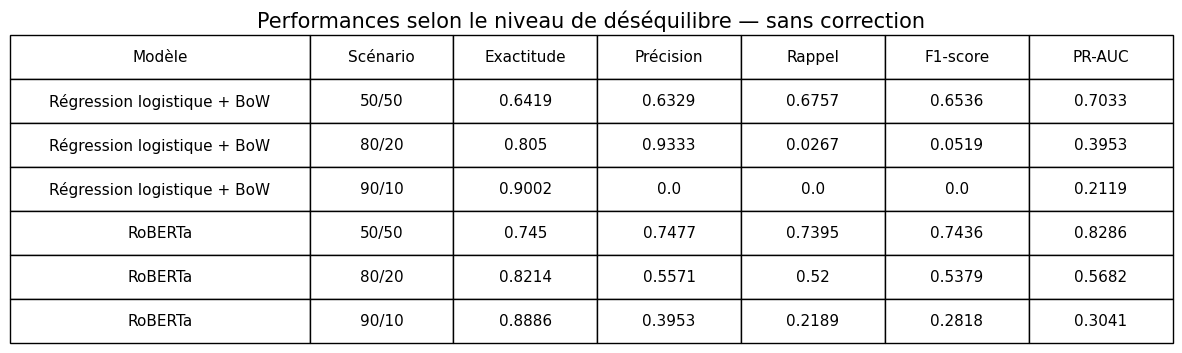

In [41]:
# Tableau récapitulatif des performances sans correction du déséquilibre
comparaison_sans_correction = pd.DataFrame([
    ["Régression logistique + BoW", "50/50", 0.6419, 0.6329, 0.6757, 0.6536, 0.7033],
    ["Régression logistique + BoW", "80/20", *metrics_ml_80_20["Valeur"].tolist()],
    ["Régression logistique + BoW", "90/10", *metrics_ml_90_10["Valeur"].tolist()],
    ["RoBERTa", "50/50", 0.7450, 0.7477, 0.7395, 0.7436, 0.8286],
    ["RoBERTa", "80/20", *metrics_roberta_80_20["Valeur"].tolist()],
    ["RoBERTa", "90/10", *metrics_roberta_90_10["Valeur"].tolist()]
], columns=[
    "Modèle", "Scénario",
    "Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"
])
# Affichage du tableau
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis("off")

table = ax.table(
    cellText=comparaison_sans_correction.values,
    colLabels=comparaison_sans_correction.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.25, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
plt.title(
    "Performances selon le niveau de déséquilibre — sans correction",
    fontsize=15
)
plt.show()

## Évaluation avec correction du déséquilibre

Afin de réduire l'effet du déséquilibre des classes, une pondération des classes est appliquée lors de l'entraînement. Cette méthode permet d'accorder davantage d'importance à la classe minoritaire sans modifier la distribution des données.

Les mêmes scénarios 80/20 et 90/10 ainsi que les mêmes configurations des modèles sont conservés afin de comparer les performances obtenues avant et après correction du déséquilibre.

### Régression logistique avec BoW
#### Scénario 80/20

In [42]:
# Scénario 80/20 avec pondération des classes
model_ml_80_20_weighted = Pipeline([
    ("text", CountVectorizer(
        ngram_range=(1, 1),
        min_df=3,
        max_df=0.8
    )),
    ("model", LogisticRegression(
        C=0.01,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])
start = time.perf_counter()
model_ml_80_20_weighted.fit(X_train_ml_80_20, y_train_ml_80_20)
time_ml_80_20_weighted = (time.perf_counter() - start) / 60
print(f"Temps d'entraînement : {time_ml_80_20_weighted:.2f} minutes")

Temps d'entraînement : 0.01 minutes


##### Évaluation sur l'ensemble de test

In [43]:
# Prédictions
y_pred_ml_80_20_weighted = model_ml_80_20_weighted.predict(X_test_ml_80_20)
y_score_ml_80_20_weighted = model_ml_80_20_weighted.predict_proba(X_test_ml_80_20)[:, 1]
# Métriques
metrics_ml_80_20_weighted = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test_ml_80_20, y_pred_ml_80_20_weighted),
        precision_score(y_test_ml_80_20, y_pred_ml_80_20_weighted, zero_division=0),
        recall_score(y_test_ml_80_20, y_pred_ml_80_20_weighted, zero_division=0),
        f1_score(y_test_ml_80_20, y_pred_ml_80_20_weighted, zero_division=0),
        average_precision_score(y_test_ml_80_20, y_score_ml_80_20_weighted)
    ]
})
metrics_ml_80_20_weighted["Valeur"] = metrics_ml_80_20_weighted["Valeur"].round(4)
metrics_ml_80_20_weighted

,Métrique,Valeur
0,Exactitude,0.6430
1,Précision,0.3068
2,Rappel,0.6229
3,F1-score,0.4111
4,PR-AUC,0.4015


#### Scénario 90/10

In [44]:
# Scénario 90/10 avec pondération des classes
model_ml_90_10_weighted = Pipeline([
    ("text", CountVectorizer(
        ngram_range=(1, 1),
        min_df=3,
        max_df=0.8
    )),
    ("model", LogisticRegression(
        C=0.01,
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])
start = time.perf_counter()
model_ml_90_10_weighted.fit(X_train_ml_90_10, y_train_ml_90_10)
time_ml_90_10_weighted = (time.perf_counter() - start) / 60
print(f"Temps d'entraînement : {time_ml_90_10_weighted:.2f} minutes")

Temps d'entraînement : 0.01 minutes


##### Évaluation sur l'ensemble de test

In [45]:
# Prédictions
y_pred_ml_90_10_weighted = model_ml_90_10_weighted.predict(X_test_ml_90_10)
y_score_ml_90_10_weighted = model_ml_90_10_weighted.predict_proba(X_test_ml_90_10)[:, 1]
# Métriques
metrics_ml_90_10_weighted = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(y_test_ml_90_10, y_pred_ml_90_10_weighted),
        precision_score(y_test_ml_90_10, y_pred_ml_90_10_weighted, zero_division=0),
        recall_score(y_test_ml_90_10, y_pred_ml_90_10_weighted, zero_division=0),
        f1_score(y_test_ml_90_10, y_pred_ml_90_10_weighted, zero_division=0),
        average_precision_score(y_test_ml_90_10, y_score_ml_90_10_weighted)
    ]
})
metrics_ml_90_10_weighted["Valeur"] = metrics_ml_90_10_weighted["Valeur"].round(4)
metrics_ml_90_10_weighted

,Métrique,Valeur
0,Exactitude,0.6808
1,Précision,0.1718
2,Rappel,0.5751
3,F1-score,0.2646
4,PR-AUC,0.2196


### RoBERTa

In [46]:
# Trainer avec pondération des classes
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

#### Scénario 80/20

In [47]:
# RoBERTa — scénario 80/20 avec pondération des classes
# Calcul des poids à partir de l'ensemble d'entraînement
class_counts_80_20 = np.bincount(y_train_dl_80_20)
class_weights_80_20 = torch.tensor(
    len(y_train_dl_80_20) / (2 * class_counts_80_20),
    dtype=torch.float
)
# Nouveau modèle avec les mêmes paramètres
roberta_model_80_20_weighted = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=2
)
roberta_args_80_20_weighted = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "roberta_80_20_weighted"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
roberta_trainer_80_20_weighted = WeightedTrainer(
    class_weights=class_weights_80_20,
    model=roberta_model_80_20_weighted,
    args=roberta_args_80_20_weighted,
    train_dataset=roberta_train_80_20,
    eval_dataset=roberta_val_80_20,
    data_collator=roberta_collator_80_20,
    compute_metrics=compute_metrics
)
roberta_train_result_80_20_weighted = roberta_trainer_80_20_weighted.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.614300,0.538397,0.769817,0.448549,0.646388,0.529595,0.569551
2,0.501400,0.565353,0.775915,0.460358,0.684411,0.550459,0.591463
3,0.390900,0.603344,0.768293,0.449132,0.688213,0.543544,0.604859


##### Évaluation sur l'ensemble de test

In [48]:
# Prédictions
roberta_output_80_20_weighted = roberta_trainer_80_20_weighted.predict(
    roberta_test_80_20
)

roberta_logits_80_20_weighted = roberta_output_80_20_weighted.predictions
roberta_y_true_80_20_weighted = roberta_output_80_20_weighted.label_ids
roberta_y_pred_80_20_weighted = np.argmax(roberta_logits_80_20_weighted, axis=1)
roberta_y_prob_80_20_weighted = torch.softmax(
    torch.tensor(roberta_logits_80_20_weighted),
    dim=1
).numpy()[:, 1]
# Métriques
metrics_roberta_80_20_weighted = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(roberta_y_true_80_20_weighted, roberta_y_pred_80_20_weighted),
        precision_score(roberta_y_true_80_20_weighted, roberta_y_pred_80_20_weighted, zero_division=0),
        recall_score(roberta_y_true_80_20_weighted, roberta_y_pred_80_20_weighted, zero_division=0),
        f1_score(roberta_y_true_80_20_weighted, roberta_y_pred_80_20_weighted, zero_division=0),
        average_precision_score(roberta_y_true_80_20_weighted, roberta_y_prob_80_20_weighted)
    ]
})
metrics_roberta_80_20_weighted["Valeur"] = (
    metrics_roberta_80_20_weighted["Valeur"].round(4)
)
metrics_roberta_80_20_weighted

,Métrique,Valeur
0,Exactitude,0.7685
1,Précision,0.4449
2,Rappel,0.6381
3,F1-score,0.5243
4,PR-AUC,0.5556


#### Scénario 90/10

In [49]:
# RoBERTa — scénario 90/10 avec pondération des classes
# Calcul des poids à partir de l'ensemble d'entraînement
class_counts_90_10 = np.bincount(y_train_dl_90_10)
class_weights_90_10 = torch.tensor(
    len(y_train_dl_90_10) / (2 * class_counts_90_10),
    dtype=torch.float
)
# Nouveau modèle avec les mêmes paramètres
roberta_model_90_10_weighted = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=2
)
roberta_args_90_10_weighted = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "roberta_90_10_weighted"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
roberta_trainer_90_10_weighted = WeightedTrainer(
    class_weights=class_weights_90_10,
    model=roberta_model_90_10_weighted,
    args=roberta_args_90_10_weighted,
    train_dataset=roberta_train_90_10,
    eval_dataset=roberta_val_90_10,
    data_collator=roberta_collator_90_10,
    compute_metrics=compute_metrics
)
roberta_train_result_90_10_weighted = roberta_trainer_90_10_weighted.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.657900,0.525899,0.742931,0.249315,0.777778,0.377593,0.313799
2,0.558700,0.505019,0.801200,0.287823,0.666667,0.402062,0.399693
3,0.462300,0.514377,0.856898,0.365591,0.581197,0.448845,0.419101


##### Évaluation sur l'ensemble de test

In [50]:
# Prédictions
roberta_output_90_10_weighted = roberta_trainer_90_10_weighted.predict(
    roberta_test_90_10
)
roberta_logits_90_10_weighted = roberta_output_90_10_weighted.predictions
roberta_y_true_90_10_weighted = roberta_output_90_10_weighted.label_ids
roberta_y_pred_90_10_weighted = np.argmax(
    roberta_logits_90_10_weighted,
    axis=1
)

roberta_y_prob_90_10_weighted = torch.softmax(
    torch.tensor(roberta_logits_90_10_weighted),
    dim=1
).numpy()[:, 1]
# Métriques
metrics_roberta_90_10_weighted = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(roberta_y_true_90_10_weighted, roberta_y_pred_90_10_weighted),
        precision_score(roberta_y_true_90_10_weighted, roberta_y_pred_90_10_weighted, zero_division=0),
        recall_score(roberta_y_true_90_10_weighted, roberta_y_pred_90_10_weighted, zero_division=0),
        f1_score(roberta_y_true_90_10_weighted, roberta_y_pred_90_10_weighted, zero_division=0),
        average_precision_score(roberta_y_true_90_10_weighted, roberta_y_prob_90_10_weighted)
    ]
})
metrics_roberta_90_10_weighted["Valeur"] = (
    metrics_roberta_90_10_weighted["Valeur"].round(4)
)
metrics_roberta_90_10_weighted

,Métrique,Valeur
0,Exactitude,0.8248
1,Précision,0.2822
2,Rappel,0.4893
3,F1-score,0.3579
4,PR-AUC,0.3112


### Tableau récapitulatif

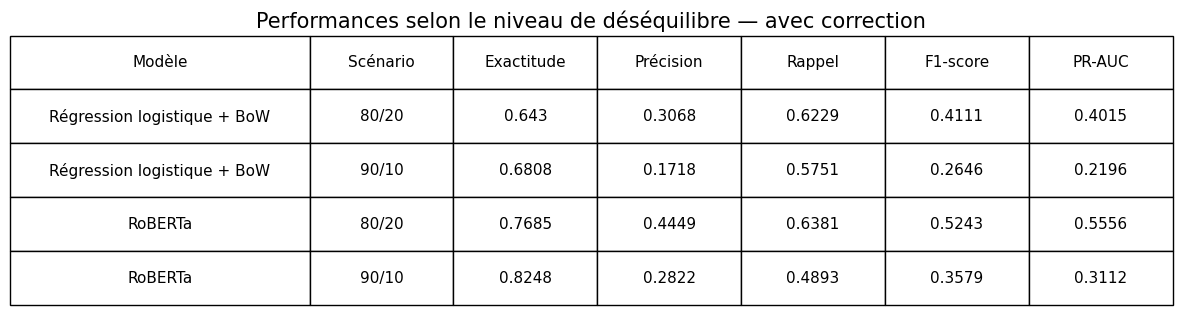

In [51]:
# Tableau récapitulatif des performances avec correction du déséquilibre
comparaison_avec_correction = pd.DataFrame([
    ["Régression logistique + BoW", "80/20", *metrics_ml_80_20_weighted["Valeur"].tolist()],
    ["Régression logistique + BoW", "90/10", *metrics_ml_90_10_weighted["Valeur"].tolist()],
    ["RoBERTa", "80/20", *metrics_roberta_80_20_weighted["Valeur"].tolist()],
    ["RoBERTa", "90/10", *metrics_roberta_90_10_weighted["Valeur"].tolist()]
], columns=[
    "Modèle", "Scénario",
    "Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"
])
# Affichage du tableau
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.axis("off")

table = ax.table(
    cellText=comparaison_avec_correction.values,
    colLabels=comparaison_avec_correction.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.25, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
plt.title(
    "Performances selon le niveau de déséquilibre — avec correction",
    fontsize=15
)
plt.show()

## Temps d'entraînement et de fine-tuning

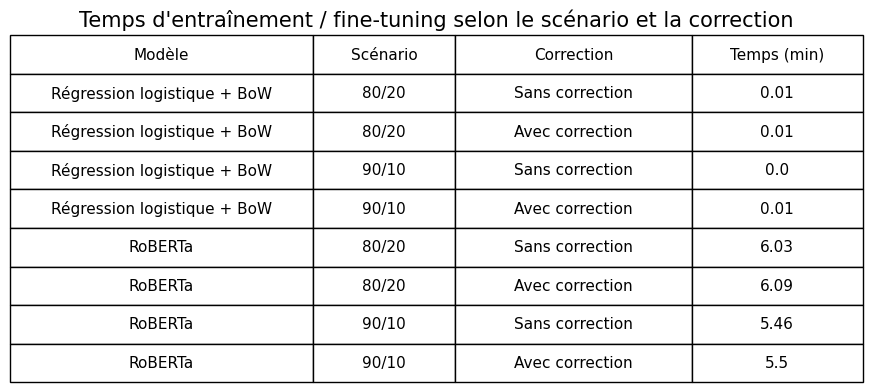

In [52]:
# Tableau récapitulatif des temps
temps_execution = pd.DataFrame([
    ["Régression logistique + BoW", "80/20", "Sans correction", time_ml_80_20],
    ["Régression logistique + BoW", "80/20", "Avec correction", time_ml_80_20_weighted],
    ["Régression logistique + BoW", "90/10", "Sans correction", time_ml_90_10],
    ["Régression logistique + BoW", "90/10", "Avec correction", time_ml_90_10_weighted],
    ["RoBERTa", "80/20", "Sans correction", roberta_train_result_80_20.metrics["train_runtime"] / 60],
    ["RoBERTa", "80/20", "Avec correction", roberta_train_result_80_20_weighted.metrics["train_runtime"] / 60],
    ["RoBERTa", "90/10", "Sans correction", roberta_train_result_90_10.metrics["train_runtime"] / 60],
    ["RoBERTa", "90/10", "Avec correction", roberta_train_result_90_10_weighted.metrics["train_runtime"] / 60]
], columns=["Modèle", "Scénario", "Correction", "Temps (min)"])

temps_execution["Temps (min)"] = temps_execution["Temps (min)"].round(2)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis("off")

table = ax.table(
    cellText=temps_execution.values,
    colLabels=temps_execution.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.32, 0.15, 0.25, 0.18]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
plt.title(
    "Temps d'entraînement / fine-tuning selon le scénario et la correction",
    fontsize=15
)
plt.show()

## Comparaison des résultats

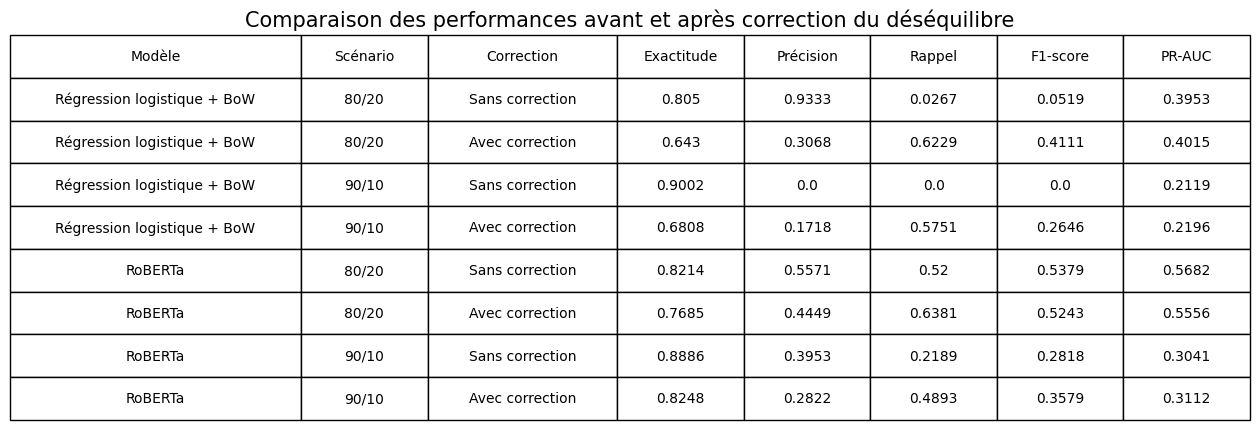

In [53]:
# Comparaison finale : sans correction vs avec correction
comparaison_finale = pd.DataFrame([
    ["Régression logistique + BoW", "80/20", "Sans correction", *metrics_ml_80_20["Valeur"].tolist()],
    ["Régression logistique + BoW", "80/20", "Avec correction", *metrics_ml_80_20_weighted["Valeur"].tolist()],
    ["Régression logistique + BoW", "90/10", "Sans correction", *metrics_ml_90_10["Valeur"].tolist()],
    ["Régression logistique + BoW", "90/10", "Avec correction", *metrics_ml_90_10_weighted["Valeur"].tolist()],
    ["RoBERTa", "80/20", "Sans correction", *metrics_roberta_80_20["Valeur"].tolist()],
    ["RoBERTa", "80/20", "Avec correction", *metrics_roberta_80_20_weighted["Valeur"].tolist()],
    ["RoBERTa", "90/10", "Sans correction", *metrics_roberta_90_10["Valeur"].tolist()],
    ["RoBERTa", "90/10", "Avec correction", *metrics_roberta_90_10_weighted["Valeur"].tolist()]
], columns=[
    "Modèle", "Scénario", "Correction",
    "Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"
])

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis("off")

table = ax.table(
    cellText=comparaison_finale.values,
    colLabels=comparaison_finale.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.23, 0.10, 0.15, 0.10, 0.10, 0.10, 0.10, 0.10]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.title(
    "Comparaison des performances avant et après correction du déséquilibre",
    fontsize=15
)
plt.show()

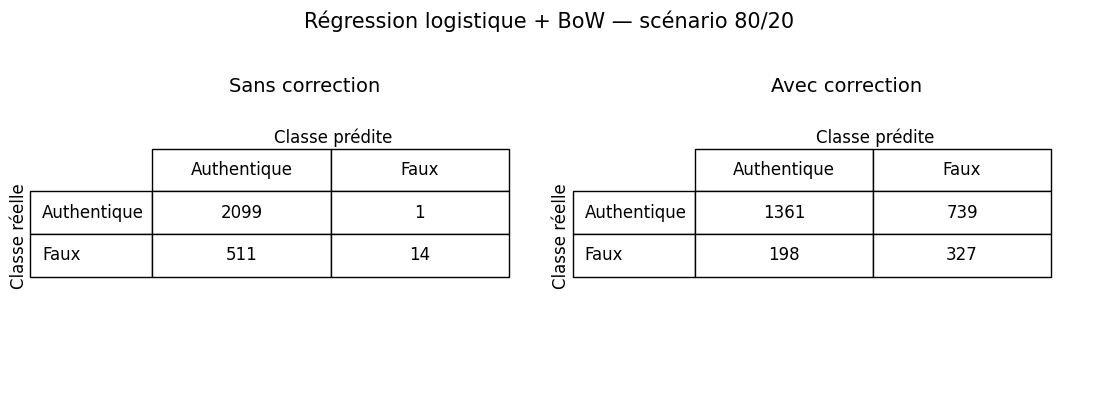

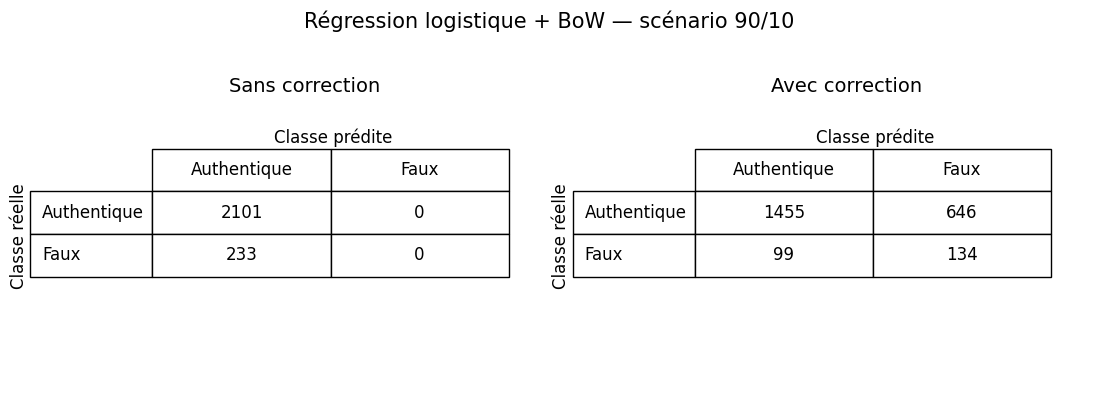

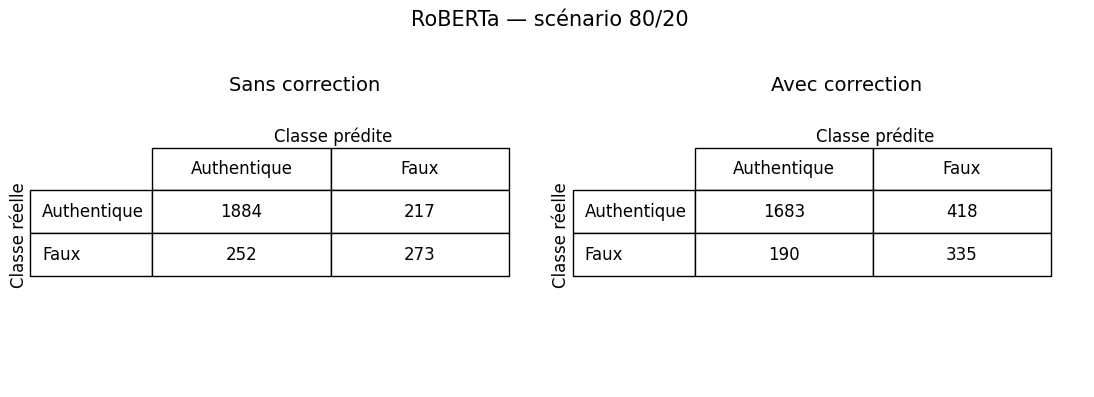

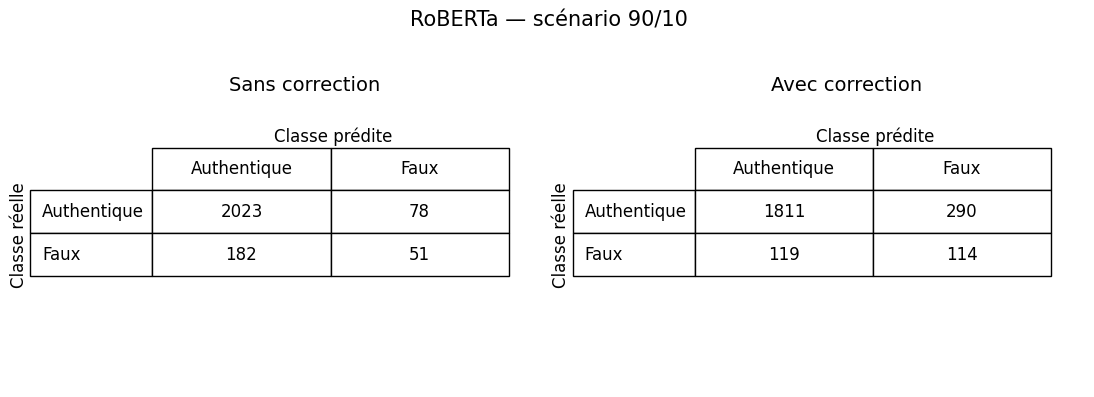

In [54]:
# Matrices de confusion avant et après correction
def afficher_matrices(y_true, y_pred_sans, y_pred_avec, modele, scenario):
    matrices = [
        confusion_matrix(y_true, y_pred_sans),
        confusion_matrix(y_true, y_pred_avec)
    ]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for ax, cm, titre in zip(
        axes,
        matrices,
        ["Sans correction", "Avec correction"]
    ):
        ax.axis("off")

        table = ax.table(
            cellText=cm,
            rowLabels=["Authentique", "Faux"],
            colLabels=["Authentique", "Faux"],
            cellLoc="center",
            bbox=[0.18, 0.38, 0.75, 0.44]
        )
        table.auto_set_font_size(False)
        table.set_fontsize(12)

        ax.text(0.56, 0.84, "Classe prédite", ha="center", fontsize=12)
        ax.text(-0.12, 0.52, "Classe réelle", va="center",
                rotation=90, fontsize=12)
        ax.set_title(titre, fontsize=14, pad=1)

    plt.suptitle(f"{modele} — scénario {scenario}", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

# Régression logistique + BoW
afficher_matrices(
    y_test_ml_80_20,
    y_pred_ml_80_20,
    y_pred_ml_80_20_weighted,
    "Régression logistique + BoW",
    "80/20"
)

afficher_matrices(
    y_test_ml_90_10,
    y_pred_ml_90_10,
    y_pred_ml_90_10_weighted,
    "Régression logistique + BoW",
    "90/10"
)

# RoBERTa
afficher_matrices(
    roberta_y_true_80_20,
    roberta_y_pred_80_20,
    roberta_y_pred_80_20_weighted,
    "RoBERTa",
    "80/20"
)

afficher_matrices(
    roberta_y_true_90_10,
    roberta_y_pred_90_10,
    roberta_y_pred_90_10_weighted,
    "RoBERTa",
    "90/10"
)